In [ ]:
!pip install osmnx networkx pandas scikit-learn

In [ ]:
import osmnx as ox
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

place_name = "Delhi, India"
G = ox.graph_from_place(place_name, network_type='drive')

nodes, edges = ox.graph_to_gdfs(G)

df = edges[['length', 'highway', 'oneway']].copy()

df['highway'] = df['highway'].astype(str)

df['highway_cat'] = df['highway'].astype('category').cat.codes

df['oneway'] = df['oneway'].astype(int)

print("Cấu trúc dữ liệu sau khi sửa lỗi:")
print(df[['highway', 'highway_cat']].head())

def simulate_travel_time(row):
    base_speed = 30
    if 'primary' in str(row['highway']): base_speed = 50
    elif 'residential' in str(row['highway']): base_speed = 20

    traffic_factor = np.random.uniform(1.0, 2.5)
    return (row['length'] / (base_speed / 3.6)) * traffic_factor

df['actual_travel_time'] = df.apply(simulate_travel_time, axis=1)

print("Dữ liệu sẵn sàng để train:")
print(df.head())

Cấu trúc dữ liệu sau khi sửa lỗi:
                             highway  highway_cat
u        v          key                          
58056528 301037382  0        primary           15
         7612915570 0      secondary           18
60890393 6436786516 0    residential           17
         6110396131 0       tertiary           20
         280740684  0        primary           15
Dữ liệu sẵn sàng để train:
                             length      highway  oneway  highway_cat  \
u        v          key                                                 
58056528 301037382  0     31.509355      primary       1           15   
         7612915570 0    325.637170    secondary       1           18   
60890393 6436786516 0     17.640539  residential       0           17   
         6110396131 0    156.010558     tertiary       1           20   
         280740684  0    621.717997      primary       1           15   

                         actual_travel_time  
u        v          key        

In [ ]:
num_nodes = len(G.nodes)
num_edges = len(G.edges)

print(f"Số lượng nút (nút giao): {num_nodes}")
print(f"Số lượng cạnh (đoạn đường): {num_edges}")

Số lượng nút (nút giao): 10159
Số lượng cạnh (đoạn đường): 24383


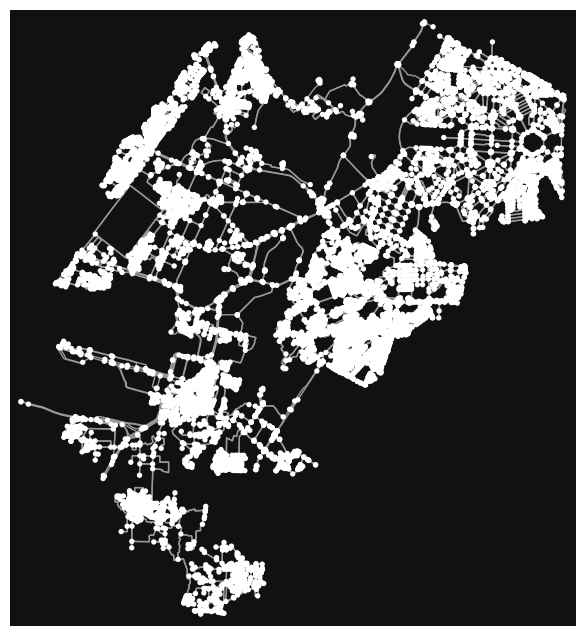

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
ox.plot_graph(G)

In [ ]:
import networkx as nx
from geopy.distance import geodesic

# 1. Giả lập dữ liệu P(Jam)
import random
def mock_jam_data(G):
    jam_preds = {}
    for u, v, k in G.edges(keys=True):
        # Giả lập xác suất kẹt xe từ 0.0 đến 1.0
        jam_preds[(u, v, k)] = random.uniform(0, 1)
    return jam_preds

In [ ]:
# 2. Thiết kế hàm tính toán trọng số thực tế (Cost Function g(n))
def update_cost_with_jam(G, jam_predictions, alpha=5.0):
    for u, v, k, data in G.edges(keys=True, data=True):
        length = data.get('length', 0)

        # Lấy xác suất kẹt xe cho cạnh này
        p_jam = jam_predictions.get((u, v, k), 0)

        # Hàm Cost thiết kế: Cost = Khoảng cách * (1 + alpha * P_jam)
        # Nếu P_jam = 1 (kẹt nặng), đoạn đường sẽ "dài" gấp (1 + alpha) lần
        data['jam_cost'] = length * (1 + alpha * p_jam)

    print(f"--- Đã cập nhật hàm Cost với hệ số phạt alpha = {alpha} ---")

In [ ]:
# 3. Thiết kế hàm Heuristic (h(n)) - Khoảng cách chim bay
def heuristic_euclidean(node, target, G):

    u_coords = (G.nodes[node]['y'], G.nodes[node]['x'])
    v_coords = (G.nodes[target]['y'], G.nodes[target]['x'])
    return geodesic(u_coords, v_coords).meters


In [ ]:
# 4. Thực thi tìm đường A*
def find_optimal_path(G, source_node, target_node):
    try:
        route = nx.astar_path(
            G,
            source=source_node,
            target=target_node,
            heuristic=lambda u, v: heuristic_euclidean(u, target_node, G),
            weight='jam_cost'
        )
        return route
    except nx.NetworkXNoPath:
        print("Không tìm thấy đường đi giữa 2 điểm này.")
        return None

--- Đã cập nhật hàm Cost với hệ số phạt alpha = 10.0 ---
Đường đi tối ưu gồm 128 nút giao thông.


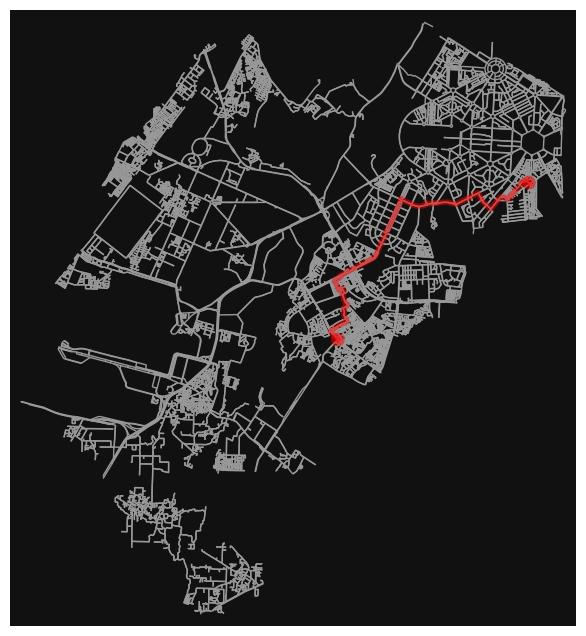

In [ ]:
# Giả sử đã có đồ thị G từ các cell trước của bạn
# Chọn ngẫu nhiên 2 điểm Start và Goal
nodes = list(G.nodes())
start_node = nodes[0]
goal_node = nodes[100] # Thay đổi tùy ý

# Cập nhật dữ liệu kẹt xe giả lập
jam_data = mock_jam_data(G)
update_cost_with_jam(G, jam_data, alpha=10.0)

# Tìm đường
optimal_route = find_optimal_path(G, start_node, goal_node)

if optimal_route:
    print(f"Đường đi tối ưu gồm {len(optimal_route)} nút giao thông.")
    # Vẽ kết quả
    ox.plot_graph_route(G, optimal_route, route_color='r', route_linewidth=4, node_size=0)